<a href="https://colab.research.google.com/github/AbhilashaChoudhary08/Experimentation-and-uplifting-modelling/blob/main/Uplift_modelling_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
!pip install -q scikit-uplift xgboost pandas numpy matplotlib
!pip install numpy==1.26.4

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklift.datasets import fetch_hillstrom
from sklift.models import SoloModel, TwoModels
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklift.metrics import uplift_at_k, qini_auc_score


In [7]:
df = pd.read_csv('Kevin_Hillstrom_MineThatData_E-MailAnalytics.csv')
y = df['visit']
treatment = df['segment']
X = df.drop(columns=['visit', 'segment', 'conversion', 'spend'])
t = treatment.map({'Womens E-Mail': 1, 'Mens E-Mail': 1, 'No E-Mail': 0})
X_encoded = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X_encoded, y, t, test_size=0.3, random_state=42)
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [8]:
eda_df = X_train.copy()
eda_df['visit'] = y_train
eda_df['treatment'] = t_train

/tmp/ipykernel_33641/2973082357.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='treatment', y='visit', data=eda_df, palette='viridis')


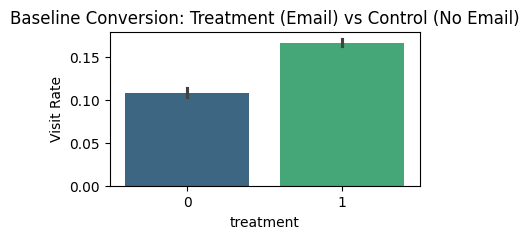

In [13]:
plt.figure(figsize=(4,2))
sns.barplot(x='treatment', y='visit', data=eda_df, palette='viridis')
plt.title('Baseline Conversion: Treatment (Email) vs Control (No Email)')
plt.ylabel('Visit Rate')
plt.show()

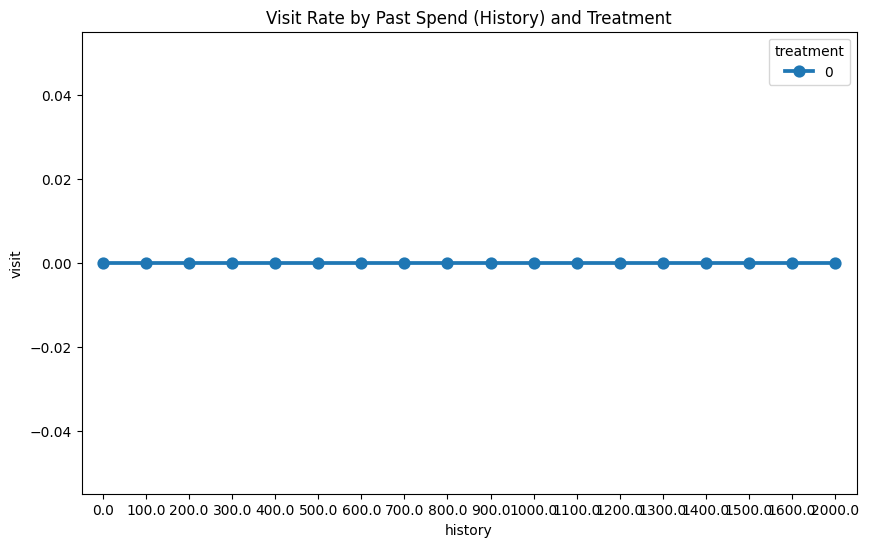

In [15]:
plt.figure(figsize=(10,6))
sns.pointplot(x='history', y='visit', hue='treatment', data=eda_df.round(-2).head(1000))
plt.title('Visit Rate by Past Spend (History) and Treatment')
plt.show()

In [16]:
param_grid = {
    'estimator__max_depth': [3, 5],
    'estimator__learning_rate': [0.1, 0.01],
    'estimator__n_estimators': [50, 100]
}

In [22]:
import warnings
warnings.filterwarnings('ignore')

s_learner = SoloModel(XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
grid_s = GridSearchCV(s_learner, param_grid, cv=3, scoring='roc_auc')
grid_s.fit(X_train, y_train, treatment=t_train)
t_learner = TwoModels(
    XGBClassifier(eval_metric='logloss'),
    XGBClassifier(eval_metric='logloss'),
    method='vanilla'
)

t_learner.fit(X_train, y_train, t_train)
s_uplift = grid_s.best_estimator_.predict(X_test)
t_uplift = t_learner.predict(X_test)

print(f"Best S-Learner Params: {grid_s.best_params_}")

Best S-Learner Params: {'estimator__learning_rate': 0.1, 'estimator__max_depth': 3, 'estimator__n_estimators': 50}


In [23]:
# Assumptions for ROI
COST_PER_EMAIL = 0.05
REVENUE_PER_VISIT = 20.00

def calculate_roi(uplift_scores, y_true, t_true, percentile=0.2):
    # Sorting by uplift score and take top K%
    n_customers = len(uplift_scores)
    threshold = np.percentile(uplift_scores, 100 * (1 - percentile))
    mask = uplift_scores >= threshold

    # Metrics for targeted group
    targeted_visits = y_true[mask].sum()
    emails_sent = mask.sum()

    # Calculating the ROI
    revenue = targeted_visits * REVENUE_PER_VISIT
    costs = emails_sent * COST_PER_EMAIL
    profit = revenue - costs

    return profit, emails_sent

In [24]:
# Comparing "Email Everyone" vs "Email Top 20% by Uplift"
profit_all, sent_all = calculate_roi(np.ones(len(y_test)), y_test, t_test, percentile=1.0)
profit_smart, sent_smart = calculate_roi(s_uplift, y_test, t_test, percentile=0.2)

print(f"--- Business Simulation Results ---")
print(f"Profit (Email Everyone): ${profit_all:,.2f}")
print(f"Profit (Uplift Targeting Top 20%): ${profit_smart:,.2f}")
print(f"Efficiency: Reduced email volume by {((sent_all-sent_smart)/sent_all)*100:.1f}%")

--- Business Simulation Results ---
Profit (Email Everyone): $55,260.00
Profit (Uplift Targeting Top 20%): $15,308.00
Efficiency: Reduced email volume by 80.0%


<Figure size 1000x600 with 0 Axes>

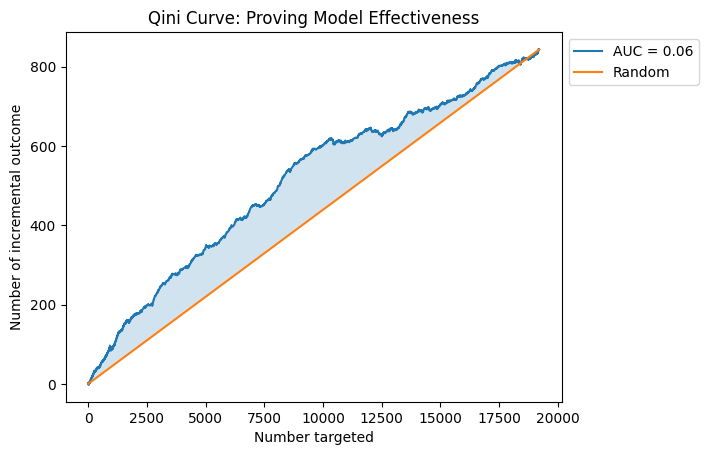

Final Qini Coefficient: 0.0559
Interpretation: A positive Qini score indicates your model successfully identified 'Persuadables'.


In [25]:
from sklift.viz import plot_qini_curve

# 1. Visualizing the Qini Curve (The Industry Standard)
# comparing the model against a 'Random' targeting strategy.
plt.figure(figsize=(10, 6))
plot_qini_curve(y_test, s_uplift, t_test, random=True, perfect=False)
plt.title('Qini Curve: Proving Model Effectiveness')
plt.show()

qini_score = qini_auc_score(y_test, s_uplift, t_test)
print(f"Final Qini Coefficient: {qini_score:.4f}")
print("Interpretation: A positive Qini score indicates your model successfully identified 'Persuadables'.")